In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import torch, numpy as np
from pathlib import Path
from config import config

In [3]:
from run_models import run_PCA, run_KMeans

d:\MSc\3. Spring 2026\CSE715\Project\vae-audio-clustering\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [4]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cuda')

In [5]:
root = Path("../..")

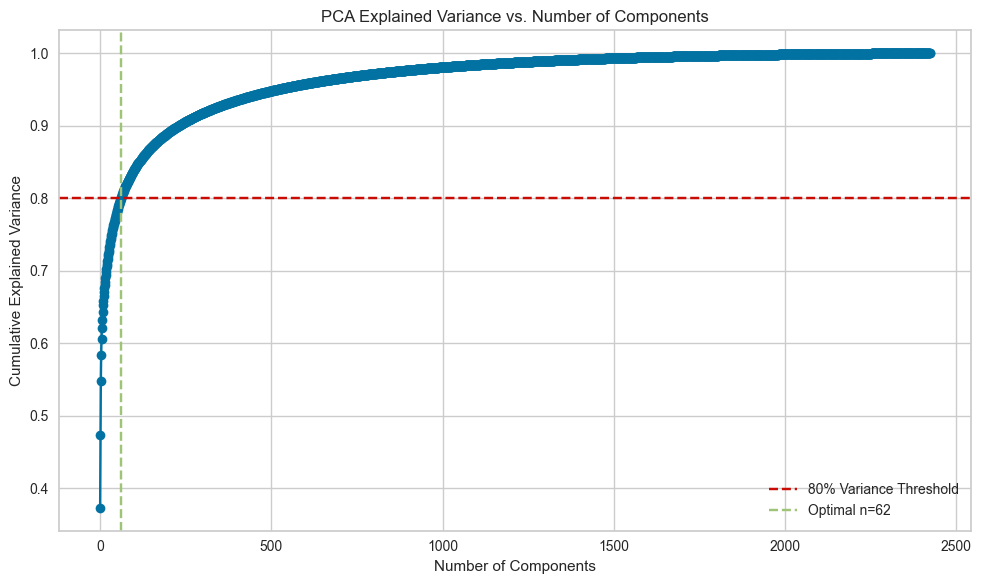

Optimal components for 80% variance: 62
Mode               : auto
Variance threshold : 80%
Components used    : 62
Variance explained : 0.8006
Train Recon MSE : 0.0043
Test  Recon MSE : 0.0042


In [6]:
pca_baseline, train_loader, test_loader, pca_history = run_PCA(root=root, model_name="easy_2_baseline_pca", variance_threshold=0.8)

In [7]:
pca_latents = np.concatenate([
    pca_baseline.transform(train_loader),
    pca_baseline.transform(test_loader)
])

In [8]:
pca_kmeans, pca_metrics = run_KMeans(pca_latents, model_type="easy_2_baseline_pca", root=root)




Optimal k        : 5
Inertia (WCSS)   : 125155.7656
Silhouette Score : 0.2021
CH Index         : 575.9388
DB Index         : 1.5758





<Figure size 800x550 with 0 Axes>

In [9]:
from visualizations import plot_tsne_clustering_comparison
from sklearn.metrics import silhouette_score

In [10]:
TSNE_DIR = root / config.TSNE_DIR
TSNE_DIR.mkdir(exist_ok=True, parents=True)

Computing t-SNE embeddings (this may take a minute)...
Saved → ..\..\results\clustering\tsne\easy_2_baseline_pca.png


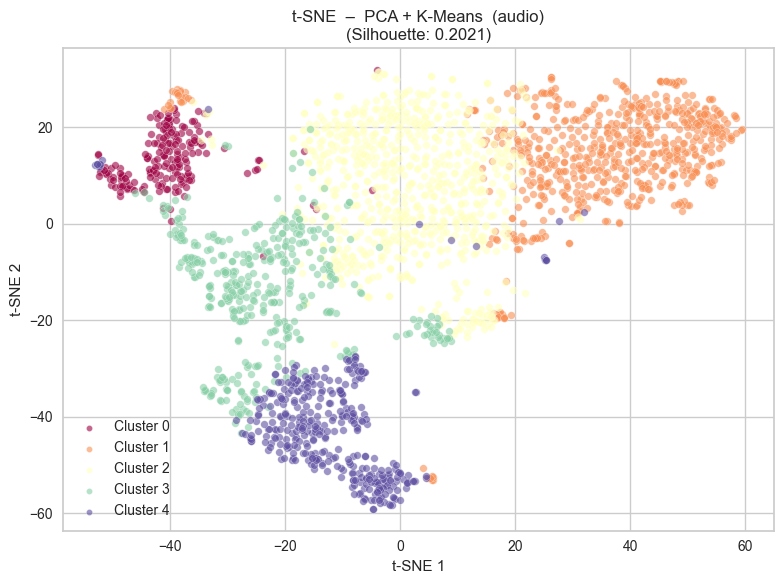

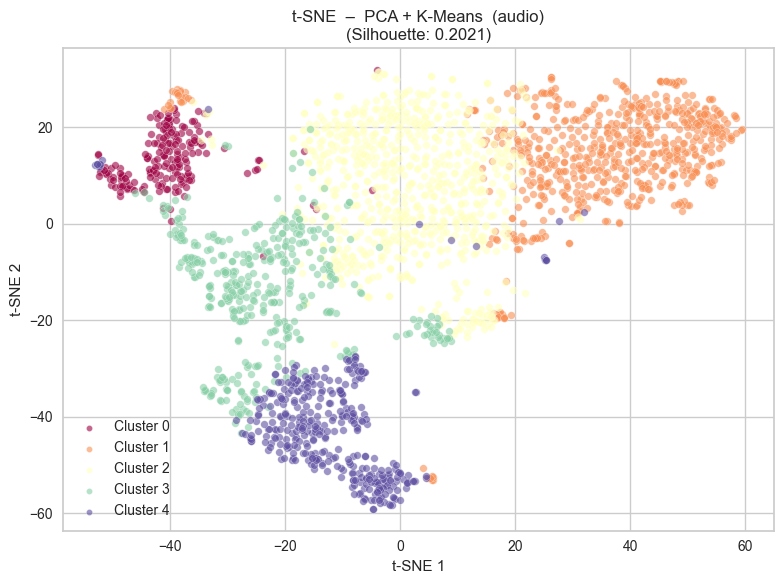

In [11]:
plot_tsne_clustering_comparison(
    pca_latents,
    [pca_kmeans.labels_, ],
    ["PCA + K-Means  (audio)", ],
    scores=[silhouette_score(pca_latents, pca_kmeans.labels_),],
    save_path=TSNE_DIR / "easy_2_baseline_pca.png"
)